# Sales Performance Analysis

Problem Statement: Organizations collect daily sales data but often lack a clear understanding of overall performance, trends, and category-wise contributions. This project focuses on analyzing sales data to extract meaningful insights.

In [1]:
# install/import the library to read and analyse the dataset
import pandas as pd

In [2]:
df = pd.read_csv("product_sales_dataset_final.csv")

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01-05-2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,03-08-2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.288,489.048,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,02-08-2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               10000 non-null  object 
 1   Branch                   10000 non-null  object 
 2   City                     10000 non-null  object 
 3   Customer type            10000 non-null  object 
 4   Gender                   10000 non-null  object 
 5   Product line             10000 non-null  object 
 6   Unit price               10000 non-null  object 
 7   Quantity                 10000 non-null  object 
 8   Tax 5%                   10000 non-null  object 
 9   Sales                    10000 non-null  object 
 10  Date                     10000 non-null  object 
 11  Time                     10000 non-null  object 
 12  Payment                  10000 non-null  object 
 13  cogs                     10000 non-null  float64
 14  gross margin percentage

In [5]:
df.describe()

,cogs,gross margin percentage,gross income,Rating
count,10000.000000,1.000000e+03,1000.000000,1000.00000
mean,171.468972,4.761905e+00,15.379369,6.97270
std,165.568805,1.421797e-14,11.708825,1.71858
min,4.360000,4.761905e+00,0.508500,4.00000
25%,62.065000,4.761905e+00,5.924875,5.50000
50%,117.685000,4.761905e+00,12.088000,7.00000
75%,221.605000,4.761905e+00,22.445250,8.50000
max,1760.890000,4.761905e+00,49.650000,10.00000


In [6]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


To handle the null values data cleaning will be done.

In [7]:
print(df.dtypes)

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                  object
Quantity                    object
Tax 5%                      object
Sales                       object
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [8]:
df['gross margin percentage'].unique()

array([4.761905,      nan])

In [9]:
df['gross margin percentage'].nunique()

1

There is only one value in this column appear everywhere. So it is better to drop this column.

In [10]:
df.drop(['gross margin percentage'], axis=1, inplace=True)

In [11]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


Next null value column is 'gross income'

In [12]:
df[['Tax 5%', 'gross income']].head()

,Tax 5%,gross income
0,26.1415,26.1415
1,3.82,3.8200
2,16.2155,16.2155
3,23.288,23.2880
4,30.2085,30.2085


After noticing that 'Tax 5%' and 'gross income' values are same, replace that.

In [13]:
(df['Tax 5%'] == df['gross income']).sum()

np.int64(0)

In [14]:
df['gross income'] = df['Tax 5%']

In [15]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


The remaining column is 'Rating'.

In [16]:
df_rating = df.dropna(subset=['Rating'])

In [17]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


# EDA

In [18]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

Performance Analysis

In [19]:
df.groupby('Branch')['Sales'].sum().sort_values(ascending=False)

,Sales
Branch,
04-06-2024,iPad ProiPad ProChildren's HoodieTempur-Pedic ...
07-13-23,iPad ProThrow PillowsCharging CableOld Navy Dr...
05-24-23,iPad ProSunglassesCharging CableThrow PillowsS...
08-21-23,iPad ProStorage RackSunglassesGoogle Pixel 7St...
11-22-24,iPad ProSony Bravia TVMacBook AirPhone CaseCar...
...,...
06-30-23,Adidas TracksuitApple iPhone 14Nike Running Sh...
11-06-2023,Adidas TracksuitAdidas TracksuitBose SoundbarI...
Giza,80.22627.6165772.38451.71417.56471.526461.3281...


In [20]:
df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Product line,
West,Clothing & ApparelHome & FurnitureElectronicsE...
Centre,Clothing & ApparelElectronicsAccessoriesElectr...
South,Clothing & ApparelClothing & ApparelClothing &...
East,Clothing & ApparelClothing & ApparelAccessorie...
Health and beauty,7821073928298410215669110736101064898538241099...
Sports and travel,7663981563910105711076279596410810786127107637...
Home and lifestyle,7102288122210694699287668510984143415105184884...
Electronic accessories,5764555946866101691010865186547999365463534144...
Fashion accessories,4125104161099519673518973104910772138124512510...


In [21]:
from re import sub
rating_df = df.dropna(subset=['Rating'])
rating_df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)

,Rating
Product line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


In [22]:
df.groupby('Product line')['gross income'].sum().sort_values(ascending=False)

,gross income
Product line,
West,SportswearKitchenwareHome AppliancesTVs & Audi...
Centre,Kids WearLaptopsSmall ElectronicsSmartphonesMe...
South,Kids WearKids WearSportswearWearablesBagsKids ...
East,FootwearKids WearBagsWearablesSmall Electronic...
Food and beverages,8.22621.5958.200522.0919.88439.489.004531.9911...
Sports and travel,30.208528.11621.78313.294535.131533.5123.40615...
Electronic accessories,3.8229.886520.6525.10211.737521.518.6427.39618...
Health and beauty,26.141523.2883.62635.6924.125513.19711.20059.6...
Fashion accessories,2.8961.6768.76723.532541.3153.5740.771529.2833...


# Visualization

In [23]:
sales_trend = (df.groupby('Date')['Sales'].sum().reset_index())

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Count Plot

In [28]:
category_sales = (
    df.groupby('Product line')['Sales']
      .sum()
      .reset_index()
      .sort_values('Sales', ascending=False)
)

print(category_sales)

             Product line                                              Sales
1                    East  CrocsCarter's OnesieWalletApple WatchPhone Cas...
0                  Centre  Carter's OnesieDell XPS 13Power BankApple iPho...
7                   South  Carter's OnesieChildren's HoodieNike Air Force...
9                    West  Adidas TracksuitInstant PotDyson VacuumLG OLED...
2  Electronic accessories  80.22627.6165433.692107.142246.4875451.71181.4...
8       Sports and travel  634.3785590.436457.443279.1845737.7615703.7527...
3     Fashion accessories  60.81635.196184.107494.1825867.61575.05416.201...
5       Health and beauty  548.9715489.04876.146749.49506.6355277.137235....
6      Home and lifestyle  340.5255772.3884.6369.72441.756253.00891.05611...
4      Food and beverages  172.746453.495172.2105463.89417.564829.08189.0...


In [29]:
print(df.columns.tolist())

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross income', 'Rating']


In [30]:
for col in df.columns:
  print(col, df[col].nunique())

Invoice ID 10000
Branch 733
City 8499
Customer type 110
Gender 49
Product line 10
Unit price 944
Quantity 14
Tax 5% 1009
Sales 1039
Date 97
Time 8991
Payment 8674
cogs 8590
gross income 1009
Rating 61


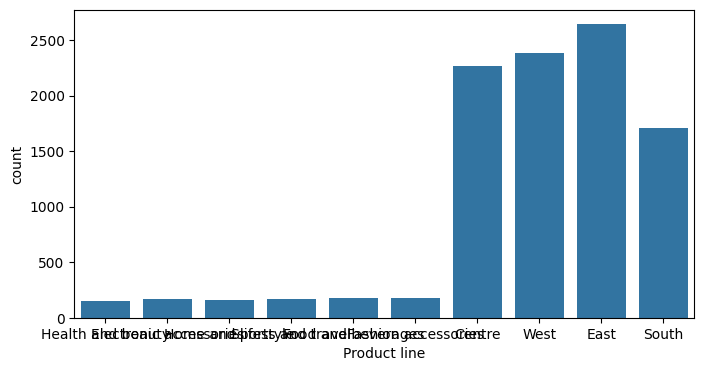

In [31]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Product line')
plt.show()

Bar Plot

In [32]:
print(df['Sales'].dtype)

object


In [33]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
print(df['Sales'].dtype)

float64


In [34]:
category_sales = (
    df.groupby('Product line')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

print(category_sales.head())

             Product line       Sales
0      Food and beverages  56144.8440
1       Sports and travel  55122.8265
2  Electronic accessories  54337.5315
3     Fashion accessories  54305.8950
4      Home and lifestyle  53861.9130


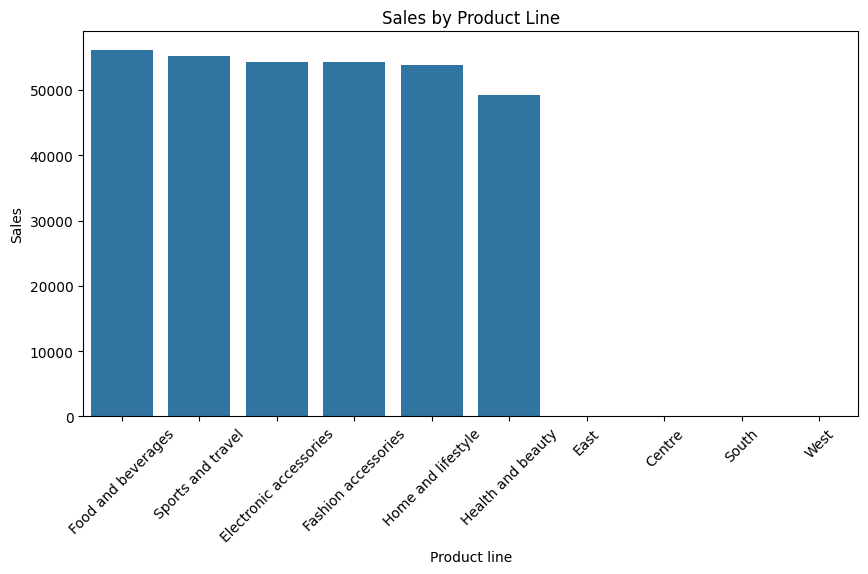

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=category_sales,
    x='Product line',
    y='Sales'
)

plt.xticks(rotation=45)
plt.title('Sales by Product Line')

plt.show()

Line Plot

In [37]:
print(df['Date'].dtype)

object


In [38]:
pd.to_datetime(
    df['Date'],
    errors='coerce'
)

,Date
0,2019-01-05
1,2019-03-08
2,2019-03-03
3,NaT
4,2019-02-08
...,...
9995,NaT
9996,NaT
9997,NaT
9998,NaT


In [39]:
invalid_dates = df[
    pd.to_datetime(df['Date'], errors='coerce').isna()
]

print(invalid_dates[['Date']].head())

        Date
3  1/27/2019
5  3/25/2019
6  2/25/2019
7  2/24/2019
9  2/20/2019


In [40]:
sales_trend = (
    df.groupby('Date')['Sales']
      .sum()
      .reset_index()
)

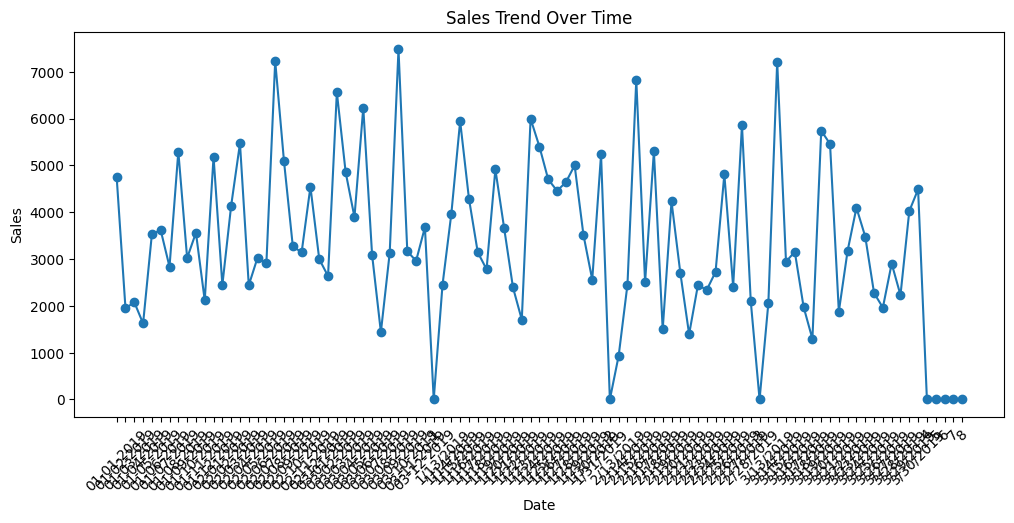

In [41]:
plt.figure(figsize=(12,5))

plt.plot(
    sales_trend['Date'],
    sales_trend['Sales'],
    marker='o'
)

plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

The given dataset has been read, analyzed, and did visualization for line plot (scatter), bar plot, and count plot.